In [8]:
import torch
import matplotlib.pyplot as plt

def plot3D(x,t,y):
    x_plot=x
    t_plot=t
    x,t = torch.meshgrid(x_plot,t_plot)
    F_xt=y
    fig,ax=plt.subplots(1,1)
    cp=ax.contour(t,x,F_xt,20,cmap='rainbow')
    fig.colorbar(cp)
    plt.show()

In [12]:
import torch
import matplotlib.pyplot as plt

def plot3D(x,t,y):
    x_plot=x
    t_plot=t
    X,T = torch.meshgrid(x_plot,t_plot)
    F_xt=y
    fig,ax=plt.subplots(1,1)
    cp=ax.contour(T,X,F_xt,20,cmap='rainbow')
    fig.colorbar(cp)
    ax.set_title('F(x,t)')
    ax.set_xlabel('t')
    ax.set_ylabel('x')
    plt.show()
    ax=plt.axes(projection='3d')
    ax.plot_surface(T.numpy(),X.numpy(),F_xt.numpy(),cmap='rainbow')
    ax.set_xlabel('t')
    ax.set_ylabel('x')
    ax.set_zlabel('f(x,t)')
    plt.show()

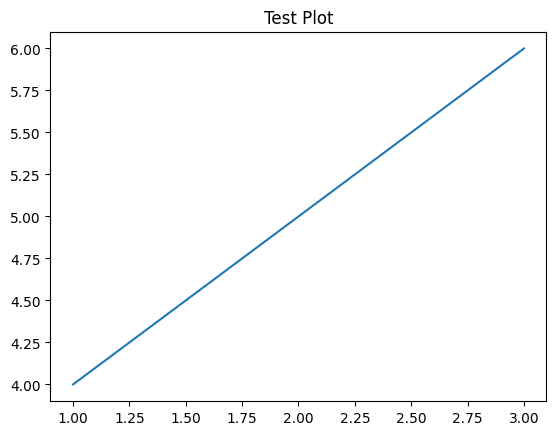

In [11]:
import torch
import matplotlib.pyplot as plt

# Force a new figure to ensure it's not hidden
plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Test Plot")
plt.show() # This should pause the script and open a window

In [16]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3D(x, t, y):
    # 1. Create Meshgrid
    X, T = torch.meshgrid(x, t, indexing='ij')
    
    # 2. Safely convert to numpy (handles GPU and Gradients)
    X_np = X.detach().cpu().numpy()
    T_np = T.detach().cpu().numpy()
    F_xt_np = y.detach().cpu().numpy()

    # --- Plot 1: 2D Contour ---
    plt.figure(figsize=(7, 5))
    # We use T_np for x-axis and X_np for y-axis to match your labels
    cp = plt.contour(T_np, X_np, F_xt_np, 20, cmap='rainbow')
    plt.colorbar(cp)
    plt.title('F(x,t) Contour')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.show()

    # --- Plot 2: 3D Surface ---
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d') # Safer way to initialize 3D
    surf = ax.plot_surface(T_np, X_np, F_xt_np, cmap='rainbow', edgecolor='none')
    
    ax.set_title('F(x,t) 3D Surface')
    ax.set_xlabel('t')
    ax.set_ylabel('x')
    ax.set_zlabel('f(x,t)')
    plt.show()

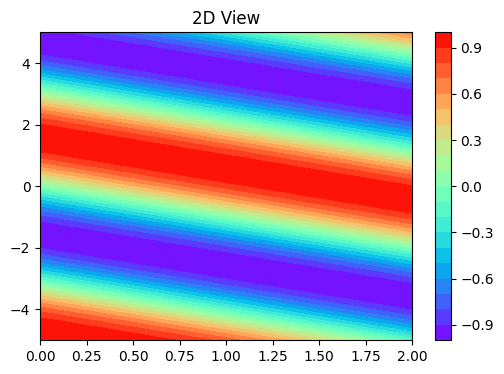

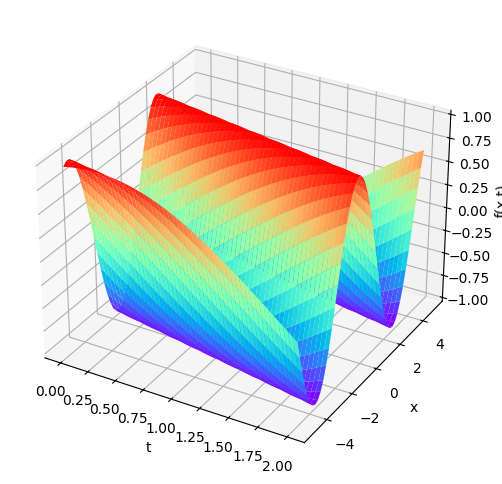

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
# This line ensures 3D support is explicitly loaded
from mpl_toolkits.mplot3d import Axes3D

def plot3D_fixed(x, t, y):
    # 1. Prepare data - using .copy() and .detach() to be 100% safe
    X_grid, T_grid = torch.meshgrid(x, t, indexing='ij')
    
    # Converting everything to numpy once at the start
    # We use .cpu() in case your tensors are on a GPU
    X_np = X_grid.detach().cpu().numpy()
    T_np = T_grid.detach().cpu().numpy()
    Y_np = y.detach().cpu().numpy()

    # --- FIGURE 1: 2D CONTOUR ---
    fig1 = plt.figure(figsize=(6, 4))
    ax1 = fig1.add_subplot(111)
    cp = ax1.contourf(T_np, X_np, Y_np, 20, cmap='rainbow')
    fig1.colorbar(cp)
    ax1.set_title("2D View")
    plt.show() # Forces Jupyter to render this figure now

    # --- FIGURE 2: 3D SURFACE ---
    fig2 = plt.figure(figsize=(8, 6))
    # We explicitly create a 3D subplot
    ax2 = fig2.add_subplot(111, projection='3d') 
    
    surf = ax2.plot_surface(T_np, X_np, Y_np, cmap='rainbow', antialiased=True)
    ax2.set_xlabel('t')
    ax2.set_ylabel('x')
    ax2.set_zlabel('f(x,t)')
    plt.show()

# --- TEST DATA (Run this to verify) ---
x_vec = torch.linspace(-5, 5, 50)
t_vec = torch.linspace(0, 2, 50)
# Create y based on the grid
X_temp, T_temp = torch.meshgrid(x_vec, t_vec, indexing='ij')
y_test = torch.sin(X_temp + T_temp)

plot3D_fixed(x_vec, t_vec, y_test)

epoch:0, Loss:4059220.250000
epoch:100, Loss:3534265.250000
epoch:200, Loss:3156561.500000
epoch:300, Loss:2867037.250000
epoch:400, Loss:2612839.500000
epoch:500, Loss:2382142.250000
epoch:600, Loss:2170215.000000
epoch:700, Loss:1974498.750000
epoch:800, Loss:1793332.375000
epoch:900, Loss:1625501.625000
epoch:1000, Loss:1470043.125000
epoch:1100, Loss:1326149.750000
epoch:1200, Loss:1193116.625000
epoch:1300, Loss:1070311.000000
epoch:1400, Loss:957155.125000
epoch:1500, Loss:853110.562500
epoch:1600, Loss:757670.625000
epoch:1700, Loss:670354.187500
epoch:1800, Loss:590701.687500
epoch:1900, Loss:518270.937500
epoch:2000, Loss:452634.531250
epoch:2100, Loss:393378.906250
epoch:2200, Loss:340101.312500
epoch:2300, Loss:292409.812500
epoch:2400, Loss:249922.234375
epoch:2500, Loss:212265.515625
epoch:2600, Loss:179076.187500
epoch:2700, Loss:149999.218750
epoch:2800, Loss:124689.875000
epoch:2900, Loss:102813.500000
epoch:3000, Loss:84045.804688
epoch:3100, Loss:68074.640625
epoch:32

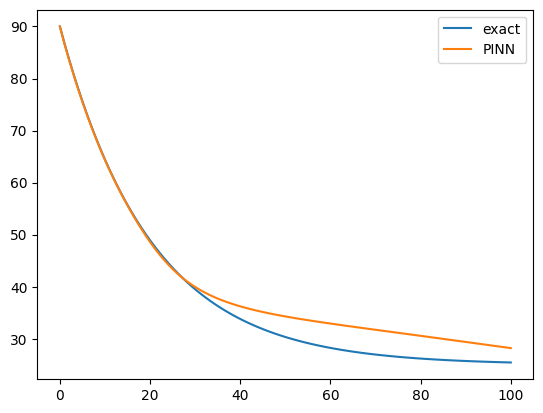

In [30]:
#studying about newton's law of cooling

import torch
import torch.nn as nn

class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(1,32), nn.Tanh(),
            nn.Linear(32,32), nn.Tanh(),
            nn.Linear(32,1)
        )
    def forward(self,t):
        return self.net(t)

model = SimplePINN()
optimizer= torch.optim.Adam(model.parameters(),lr=0.001)

T_env=25.0
k=0.05#cooling rate
T_i = 90 #inital temp

#Training loop
for epoch in range(30000):#one epoch is one fulll lap , it is batch and not a single iteration
    optimizer.zero_grad()

    t_physics = torch.linspace(0,10,100).view(-1,1).requires_grad_(True)
    T_pred= model(t_physics)

    q= torch.autograd.grad(T_pred,t_physics,grad_outputs=torch.ones_like(T_pred),create_graph=True)[0]

    loss_physics = torch.mean((q+k*(T_pred- T_env))**2)
    loss_initial= torch.mean((model(torch.tensor([[0.0]]))-T_i)**2)

    loss = loss_physics+500*loss_initial
    loss.backward()
    optimizer.step()

    if epoch %100 ==0:
        print(f"epoch:{epoch}, Loss:{loss.item():.6f}")

#visulazation
t_test = torch.linspace(0,100,100).view(-1,1)
T_final_pred = model(t_test).detach().numpy()
T_analytical = T_env +(T_i -T_env)*torch.exp(-k*t_test).numpy()
plt.plot(t_test.numpy(),T_analytical,label='exact')
plt.plot(t_test.numpy(),T_final_pred,label='PINN')
plt.legend()
plt.show()

    

In [31]:
t1= torch.tensor(4.)
t1

tensor(4.)

In [32]:
t1.dtype

torch.float32

In [33]:
t1.shape


torch.Size([])

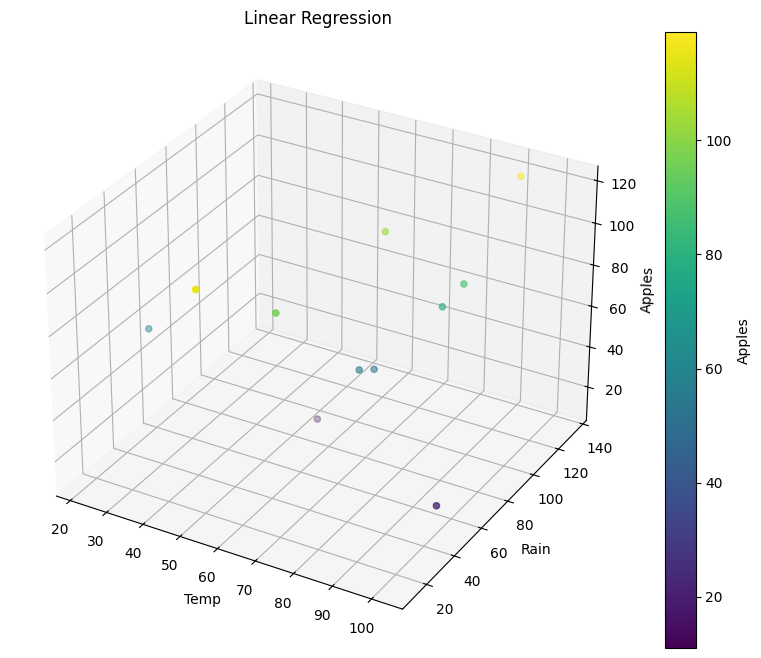

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

Temp=[73,87,91,102,69,22,52,63,89,74,55]
Rain=[67,88,134,43,96,52,12,36,98,75,85]
Apples=[56,81,119,22,103,58,115,96,87,52,11]

T= np.array(Temp)
R= np.array(Rain)
A=np.array(Apples)

fig =plt.figure(figsize=(10,8))
ax= fig.add_subplot(111, projection='3d')

sc= ax.scatter(T,R,A,c=A, cmap='viridis', marker='o')
plt.colorbar(sc,ax=ax,label='Apples')
ax.set_xlabel('Temp')
ax.set_ylabel('Rain')
ax.set_zlabel('Apples')
ax.set_title('Linear Regression')

plt.show()

In [36]:
inputs=np.array([[73,67,43],
                [91,88,64],
                [87,134,58],
                [102,43,37],
                [69,96,70]],dtype='float32')

targets=np.array([[56,70],
                 [81,101],
                 [119,133],
                 [22,37],
                 [103,119]],dtype='float32')

inputs= torch.from_numpy(inputs) #conversion from numpy to tensors
targets=torch.from_numpy(targets)
print(inputs)
print(targets)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])


In [38]:
w= torch.randn(2,3,requires_grad=True)#weight has 2 rows and 3 colums
b=torch.randn(2,requires_grad=True)#bias has 2 rows only
print(w)
print(b)# we are starting with random weight and bias

tensor([[ 0.4689, -0.6979,  2.0973],
        [-0.4593, -0.1168,  1.1651]], requires_grad=True)
tensor([-1.5771, -1.2950], requires_grad=True)


In [39]:
def model(x):
    return x @ w.t()+b #@represts matrix multiplication in tensor , w.t is wight matri transpose

prediction = model(inputs)
print(prediction)

tensor([[ 76.0745,   7.4503],
        [113.9011,  21.1973],
        [ 67.3372,  10.6717],
        [ 93.8392, -10.0569],
        [110.5856,  37.3581]], grad_fn=<AddBackward0>)


In [43]:
#according to prediction the orage goes to negative so it is worng , as w, b are random
#Loss function: Mean squared error

diff= prediction-targets
loss= torch.sum(diff*diff)/diff.numel()
print(loss)

def mse(t1,t2):
    diff= t1-t2
    return torch.sum(diff*diff)/diff.numel()
loss=mse(prediction,targets)
#loss is function of weight

tensor(4349.7817, grad_fn=<DivBackward0>)


In [51]:
print(w.grad)

tensor([[ 1563.1564,   226.9554,   632.2949],
        [-6580.7656, -7493.3042, -4469.6172]])


In [52]:
w.grad.zero_()
b.grad.zero_()#set gradient back to zero as pytorch accumaltes graidents

prediction =model(inputs)
print(prediction) 

tensor([[ 76.0745,   7.4503],
        [113.9011,  21.1973],
        [ 67.3372,  10.6717],
        [ 93.8392, -10.0569],
        [110.5856,  37.3581]], grad_fn=<AddBackward0>)


In [53]:
loss= mse(prediction,targets)
print(loss)

tensor(4349.7817, grad_fn=<DivBackward0>)


In [54]:
loss.backward() #graidnt of loss
print(w.grad)
print(b.grad)

tensor([[ 1563.1564,   226.9554,   632.2949],
        [-6580.7656, -7493.3042, -4469.6172]])
tensor([ 16.1475, -78.6759])


In [59]:
#adjust weight and reset gradients
with torch.no_grad():
    w -= w.grad *1e-7 #learning rate
    b -= b.grad*1e-7
    w.grad.zero_()
    b.grad.zero_()

print(w)
print(b)

tensor([[-0.4848,  0.2560,  1.8028],
        [-0.3384,  0.5924,  1.3154]], requires_grad=True)
tensor([-1.5865, -1.2932], requires_grad=True)


In [60]:
for i in range(200):
    prediction = model(inputs)
    loss=mse(prediction,targets)
    loss.backward()
    with torch.no_grad():
        w -= w.grad *1e-5
        b -= b.grad*1e-5
        w.grad.zero_()
        b.grad.zero_()

print(prediction)
print(targets)

tensor([[ 56.5730,  69.9418],
        [ 89.7735, 103.4275],
        [102.4312, 127.2739],
        [ 19.9873,  36.4418],
        [115.4091, 124.0141]], grad_fn=<AddBackward0>)
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])


In [64]:
import torch.nn as nn
inputs=np.array([[73,67,43],
                [91,88,64],
                [87,134,58],
                [102,43,37],
                [69,96,70],
                [78,52,63],
                [88,45,32],
                [84,52,10],
                [88,52,32],
                [21,35,84]],dtype='float32')

targets=np.array([[73,67],
                 [91,88],
                 [87,134],
                 [102,43],
                 [69,96],
                 [56,70],
                 [81,101],
                 [119,133],
                 [22,37],
                 [103,119]],dtype='float32')

from torch.utils.data import TensorDataset
#Define Dataset

inputs= torch.from_numpy(inputs)
targets=torch.from_numpy(targets)
train_ds = TensorDataset(inputs,targets)
train_ds[0:3]

(tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [ 87., 134.,  58.]]),
 tensor([[ 73.,  67.],
         [ 91.,  88.],
         [ 87., 134.]]))

In [65]:
from torch.utils.data import DataLoader
batch_size=5
train_dl= DataLoader(train_ds,batch_size,shuffle=True)

In [66]:
for xb,yb in train_dl:
    print(xb)
    print(yb)
    

tensor([[88., 52., 32.],
        [84., 52., 10.],
        [91., 88., 64.],
        [69., 96., 70.],
        [78., 52., 63.]])
tensor([[ 22.,  37.],
        [119., 133.],
        [ 91.,  88.],
        [ 69.,  96.],
        [ 56.,  70.]])
tensor([[ 73.,  67.,  43.],
        [ 21.,  35.,  84.],
        [ 88.,  45.,  32.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.]])
tensor([[ 73.,  67.],
        [103., 119.],
        [ 81., 101.],
        [ 87., 134.],
        [102.,  43.]])


In [68]:
model = nn.Linear(3,2) #3inputs, 2outputs
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[ 0.2847,  0.4074, -0.0394],
        [-0.3069, -0.1706,  0.1835]], requires_grad=True)
Parameter containing:
tensor([0.1860, 0.4228], requires_grad=True)


In [69]:
import torch.nn.functional as F
loss_fn = F.mse_loss

loss= loss_fn(model(inputs),targets)
print(loss)

tensor(8143.3174, grad_fn=<MseLossBackward0>)


In [73]:
opt = torch.optim.SGD(model.parameters(),lr=1e-5)#Stochastic gradient descent

def fit(epoch, model,loss_fn,opt,train_dl):
    for num in range(epoch):
        for xb,yb in train_dl:
            prediction= model(xb)
            loss= loss_fn(prediction,yb)
            loss.backward()
            opt.step()#update parameters using gradient
            opt.zero_grad()
        if (num+1)%10 == 0:
            print('Epoch[{}/{}],Loss:{:.4f}'.format(num+1,epoch, loss))

fit(800,model,loss_fn,opt,train_dl)

Epoch[10/800],Loss:686.5334
Epoch[20/800],Loss:772.6030
Epoch[30/800],Loss:1596.7336
Epoch[40/800],Loss:722.8846
Epoch[50/800],Loss:636.8640
Epoch[60/800],Loss:1187.0701
Epoch[70/800],Loss:710.8864
Epoch[80/800],Loss:1265.3035
Epoch[90/800],Loss:317.7591
Epoch[100/800],Loss:794.2574
Epoch[110/800],Loss:688.4550
Epoch[120/800],Loss:1868.7994
Epoch[130/800],Loss:456.0696
Epoch[140/800],Loss:1679.8337
Epoch[150/800],Loss:1177.7021
Epoch[160/800],Loss:725.5179
Epoch[170/800],Loss:956.3890
Epoch[180/800],Loss:1615.2742
Epoch[190/800],Loss:1270.9543
Epoch[200/800],Loss:1429.6846
Epoch[210/800],Loss:1359.2115
Epoch[220/800],Loss:767.7917
Epoch[230/800],Loss:666.3922
Epoch[240/800],Loss:1278.9656
Epoch[250/800],Loss:1840.6119
Epoch[260/800],Loss:1660.4186
Epoch[270/800],Loss:1186.3475
Epoch[280/800],Loss:1615.6974
Epoch[290/800],Loss:648.7080
Epoch[300/800],Loss:635.1946
Epoch[310/800],Loss:1508.6958
Epoch[320/800],Loss:737.2161
Epoch[330/800],Loss:688.6906
Epoch[340/800],Loss:365.4824
Epoch[3

In [74]:
prediction= model(inputs)
prediction

tensor([[ 70.3891,  80.3936],
        [ 93.9014, 108.5130],
        [ 83.7693, 128.4272],
        [ 87.7217,  71.8203],
        [ 82.4870, 110.4313],
        [ 87.5491,  85.3543],
        [ 75.1300,  66.2774],
        [ 58.0092,  56.1665],
        [ 74.5686,  69.9990],
        [ 64.4507,  73.4338]], grad_fn=<AddmmBackward0>)

In [75]:
import torch
import torchvision
from torchvision.datasets import MNIST

In [76]:
dataset = MNIST(root='data/', download = True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:04<00:00, 2.02MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 121kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]


In [78]:
#this downloads the dataset into the root folder where the notebook is running

len(dataset) #no of images in the dataset 

test_dataset = MNIST(root='data/', train= False)

In [79]:
dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

label: 3


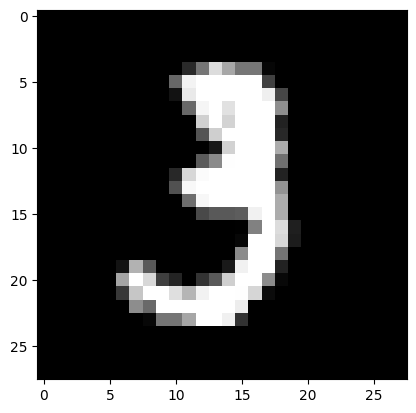

In [83]:
#PIL Image is part of python library pillow, 5 is the number of the image, therefore supervised learning.
#Train data already has label. 28*28 pixel, pillow is python labelling library

import matplotlib.pyplot as plt
%matplotlib inline

image,label = dataset[10]
plt.imshow(image,cmap='gray')
print('label:',label)

In [84]:
import torchvision.transforms as transforms #this transforms images to tensors

#MNIST dataset
dataset= MNIST(root='data/', train = True, transform = transforms.ToTensor())

image, label = dataset[3]
print(image.shape, label)

torch.Size([1, 28, 28]) 1


In [85]:
#1,28,28: 1 says colorscale which is gray so its 1, 28 says the pixel 

print(image[:,10:15,10:15])
print(torch.max(image), torch.min(image))

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0784],
         [0.0000, 0.0000, 0.0000, 0.1255, 0.8039],
         [0.0000, 0.0000, 0.0000, 0.4078, 0.9843],
         [0.0000, 0.0000, 0.3137, 0.9412, 0.9843]]])
tensor(1.) tensor(0.)


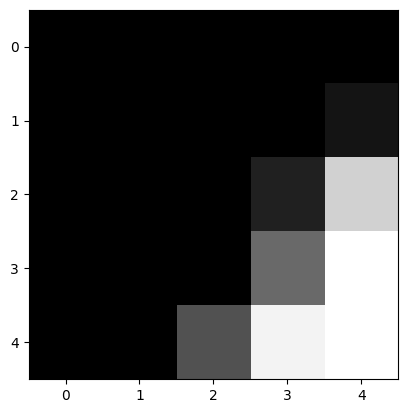

In [87]:
plt.imshow(image[0,10:15,10:15],cmap='gray')

In [89]:
from torch.utils.data import random_split #split the data randomly into training and calidation data

train_ds, val_ds= random_split(dataset,[50000,10000])
len(train_ds), len(val_ds)

(50000, 10000)

In [90]:
from torch.utils.data import DataLoader
batch_size = 128
train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader= DataLoader(val_ds, batch_size)

In [91]:
import torch.nn as nn
input_size = 28*28 #linear expexts single inputs so flatten out to vector instead of tensor
num_classes = 10 #10 possible categories of output, each output has vector size 10

#Logistic regression model

model = nn.Linear(input_size, num_classes)

print(model.weight.shape)
model.weight

torch.Size([10, 784])


Parameter containing:
tensor([[-0.0029,  0.0198, -0.0311,  ...,  0.0217,  0.0107,  0.0075],
        [ 0.0045, -0.0323, -0.0062,  ..., -0.0338,  0.0267,  0.0071],
        [ 0.0162, -0.0166,  0.0143,  ..., -0.0022, -0.0263, -0.0121],
        ...,
        [ 0.0002, -0.0145,  0.0297,  ..., -0.0018, -0.0180, -0.0212],
        [-0.0060,  0.0121, -0.0080,  ..., -0.0198, -0.0124,  0.0252],
        [-0.0200,  0.0269, -0.0114,  ..., -0.0003, -0.0335,  0.0347]],
       requires_grad=True)

In [92]:
print(model.bias.shape)
model.bias

torch.Size([10])


Parameter containing:
tensor([ 0.0229, -0.0186, -0.0157, -0.0270,  0.0205, -0.0082,  0.0326,  0.0100,
         0.0277, -0.0031], requires_grad=True)

In [93]:
for images, label in train_loader:
    print(label)
    print(images.shape)
    output= model(images)
    break

tensor([2, 5, 6, 9, 9, 6, 8, 5, 8, 2, 0, 1, 7, 7, 7, 4, 2, 1, 0, 6, 4, 3, 1, 5,
        9, 6, 5, 4, 3, 2, 4, 8, 9, 6, 4, 7, 9, 9, 2, 1, 4, 0, 4, 3, 5, 0, 9, 1,
        5, 7, 3, 4, 1, 9, 0, 4, 9, 7, 7, 3, 6, 3, 4, 9, 3, 4, 7, 8, 1, 0, 1, 1,
        3, 7, 6, 6, 2, 9, 6, 1, 6, 5, 8, 9, 7, 8, 5, 3, 3, 6, 0, 3, 8, 6, 4, 8,
        3, 7, 6, 9, 7, 8, 8, 9, 6, 7, 4, 8, 1, 8, 9, 1, 0, 7, 0, 9, 4, 9, 6, 6,
        5, 3, 4, 7, 0, 9, 3, 5])
torch.Size([128, 1, 28, 28])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)

In [94]:
class MnistModel(nn.Module): #nn.Module class to extend the pytorch module, image size is vector and we need tensor
    def __init__(self):#constructor 
        super().__init__()
        self.linear = nn.Linear(input_size,num_classes) #self.linear will be nn.linear

    def forward(self,xb): #self is mdel itself, frwd gets batch of data and flattens it out
        xb= xb.reshape(-1,784)
        out = self.linear(xb)
        return out
        
model = MnistModel()

In [95]:
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[ 0.0302,  0.0022, -0.0108,  ..., -0.0335, -0.0163,  0.0189],
         [ 0.0286,  0.0007,  0.0323,  ...,  0.0330, -0.0323,  0.0273],
         [-0.0266, -0.0047, -0.0079,  ..., -0.0245,  0.0176,  0.0110],
         ...,
         [-0.0290, -0.0213,  0.0244,  ..., -0.0283, -0.0293, -0.0038],
         [-0.0057,  0.0195,  0.0125,  ..., -0.0025,  0.0195, -0.0177],
         [ 0.0023,  0.0280,  0.0316,  ..., -0.0264, -0.0265, -0.0341]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0286,  0.0088, -0.0054,  0.0098,  0.0314, -0.0071,  0.0315,  0.0192,
          0.0171, -0.0195], requires_grad=True)]

In [96]:
for images,label in train_loader:
    outputs= model(images)
    break
print('output.shape:',outputs.shape)
print('Sample output:\n',outputs[:2].data)

output.shape: torch.Size([128, 10])
Sample output:
 tensor([[-0.1689,  0.2812, -0.1630, -0.0236,  0.0824, -0.1415, -0.0829,  0.0104,
         -0.0485,  0.0025],
        [ 0.0390,  0.1158, -0.0574,  0.0952,  0.1951,  0.0276,  0.0128, -0.0443,
         -0.1874, -0.0465]])


In [99]:
import torch.nn.functional as F
probs= F.softmax(outputs,dim=1)#0 dimesnion is dimension of batches
print('Sample probabilities:\n', probs[:2].data)
print('Sum:', torch.sum(probs[0]).item())

Sample probabilities:
 tensor([[0.0859, 0.1347, 0.0864, 0.0993, 0.1104, 0.0883, 0.0936, 0.1027, 0.0969,
         0.1019],
        [0.1019, 0.1100, 0.0925, 0.1078, 0.1191, 0.1008, 0.0993, 0.0938, 0.0813,
         0.0936]])
Sum: 1.0000001192092896


In [100]:
max_probs, preds = torch.max(probs,dim=1)
print(preds)
print(max_probs)

tensor([1, 4, 3, 6, 3, 1, 3, 1, 1, 3, 1, 3, 1, 1, 7, 1, 3, 7, 3, 3, 7, 8, 6, 3,
        1, 1, 4, 1, 3, 3, 3, 1, 1, 3, 7, 4, 3, 3, 3, 4, 3, 3, 3, 1, 1, 3, 1, 4,
        1, 3, 1, 1, 4, 3, 3, 0, 3, 1, 5, 3, 1, 3, 7, 3, 3, 7, 3, 4, 4, 1, 7, 3,
        1, 8, 4, 4, 3, 1, 4, 1, 1, 1, 3, 1, 3, 7, 8, 1, 3, 3, 7, 7, 4, 7, 4, 1,
        1, 3, 3, 1, 1, 8, 3, 3, 3, 3, 6, 4, 1, 1, 1, 1, 3, 1, 3, 4, 3, 1, 3, 4,
        1, 3, 7, 3, 1, 0, 3, 3])
tensor([0.1347, 0.1191, 0.1159, 0.1166, 0.1386, 0.1210, 0.1206, 0.1265, 0.1238,
        0.1249, 0.1484, 0.1820, 0.1363, 0.1303, 0.1312, 0.1557, 0.1262, 0.1191,
        0.1342, 0.1480, 0.1228, 0.1166, 0.1287, 0.1365, 0.1406, 0.1402, 0.1253,
        0.1224, 0.1228, 0.1366, 0.1142, 0.1454, 0.1534, 0.1332, 0.1356, 0.1408,
        0.1326, 0.1193, 0.1346, 0.1522, 0.1234, 0.1374, 0.1165, 0.1235, 0.1314,
        0.1322, 0.1297, 0.1338, 0.1544, 0.1501, 0.1270, 0.1711, 0.1441, 0.1309,
        0.1309, 0.1112, 0.1661, 0.1268, 0.1198, 0.1405, 0.1755, 0.1560, 0.1258,
       

In [102]:
label

tensor([2, 1, 6, 3, 5, 6, 6, 4, 6, 4, 5, 0, 7, 3, 8, 7, 7, 9, 0, 0, 7, 6, 4, 2,
        2, 2, 9, 2, 6, 6, 3, 9, 6, 5, 8, 9, 6, 1, 6, 9, 6, 4, 4, 9, 4, 1, 6, 7,
        8, 6, 1, 8, 8, 5, 6, 0, 0, 9, 7, 0, 2, 5, 9, 7, 1, 1, 6, 9, 4, 3, 2, 5,
        2, 7, 6, 7, 8, 4, 3, 8, 9, 6, 5, 3, 5, 0, 7, 6, 6, 1, 9, 6, 8, 8, 2, 7,
        2, 8, 0, 6, 7, 9, 0, 6, 8, 1, 8, 6, 2, 8, 7, 8, 6, 6, 1, 4, 0, 7, 6, 7,
        7, 6, 5, 0, 6, 3, 1, 0])

In [103]:
def accuracy(outputs,label):#element wise comparison of the outputs and label
    _,preds= torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds==label).item()/len(preds))

In [104]:
accuracy(outputs,label)

tensor(0.0469)

In [105]:
#Accuracy is not differentialble functional as it is element wise , torch.max is also not differentialble
#loss functional commmonly used is 'cross function'; label is cnverted to vector encoded 
loss_fn = F.cross_entropy
loss = loss_fn(outputs,label) #perfroms softmax 
print(loss)



tensor(2.3532, grad_fn=<NllLossBackward0>)


In [106]:
#Train the model: Addition of validation phase
#for epoch in range(num_epcoch);
#for batch in train_loader:
#Generate predictions
#Calculate loss
#compute graidents
#update wifhr
#reset graidents
#Validation phase
#for batch in val_loader
#Generate predictions
#calculate loss
#calculate metrics
#calculate avg validation loss & metrics




In [117]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear= nn.Linear(input_size,num_classes)

    def forward(self,xb):
        xb = xb.reshape(-1,784)
        out = self.linear(xb)
        return out

    def training_step(self,batch):
        images, label = batch 
        out = self(images)
        loss = F.cross_entropy(out,label)
        return loss

    def validation_step(self,batch):
        images, label = batch
        out = self(images)
        loss = F.cross_entropy(out, label)
        acc= accuracy(out, label)
        return {'Val_loss':loss,'val_acc':acc}

    def validation_epoch_end(self, outputs):
        batch_losses =[x['Val_loss']for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_acc = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_acc).mean()
        return {'Val_loss':epoch_loss.item(),'val_acc': epoch_acc.item()}

    def epoch_end(self,epoch,result):
        print('Epoch[{}],Val_loss:{:.4f},val_acc:{:.4f}'.format(epoch,result['Val_loss'],result['val_acc']))

model = MnistModel()

In [118]:
#define evaluate function and fit function

def evaluate(model,val_loader):
    outputs= [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr ,model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(),lr)
    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model,val_loader)
        model.epoch_end(epoch,result)
        history.append(result)
    return history

result0= evaluate(model, val_loader)
result0

{'Val_loss': 2.3223321437835693, 'val_acc': 0.09523338824510574}

In [119]:
history1 = fit(5,0.001,model, train_loader, val_loader)

Epoch[0],Val_loss:1.9496,val_acc:0.6188
Epoch[1],Val_loss:1.6788,val_acc:0.7336
Epoch[2],Val_loss:1.4765,val_acc:0.7674
Epoch[3],Val_loss:1.3238,val_acc:0.7861
Epoch[4],Val_loss:1.2064,val_acc:0.8012


Text(0.5, 1.0, 'Accuracy vs No of epochs')

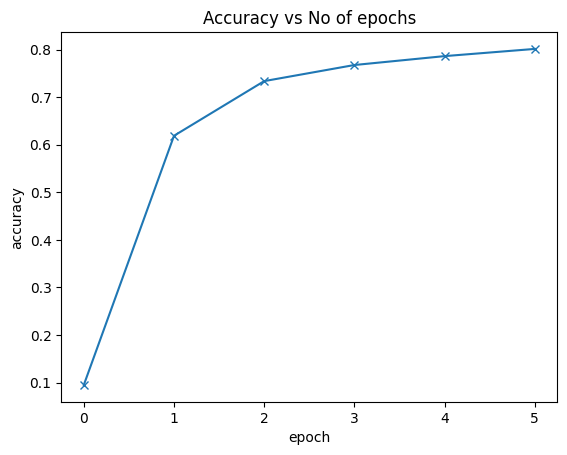

In [120]:
history = [result0]+history1
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs No of epochs')

label 5


torch.Size([1, 1, 28, 28])

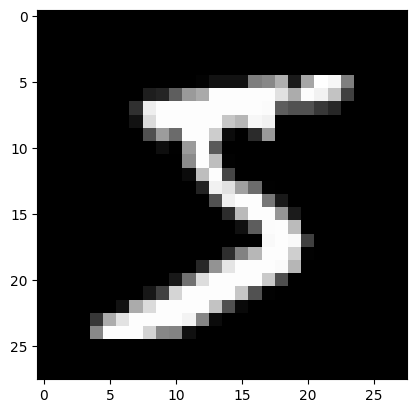

In [123]:
test_dataset = MNIST(root ='data/', train= False, transform = transforms.ToTensor())
img, label = dataset[0]
plt.imshow(img[0],cmap='gray')
print('label',label)

img.unsqueeze(0).shape #to add the batch dimension in the shape

In [124]:
def predict_image(img, model):
    xb= img.unsqueeze(0)
    yb= model(xb)
    _,preds = torch.max(yb, dim=1) #prediction is index of highest probability
    return preds[0].item()

Label 7 Predicted 7


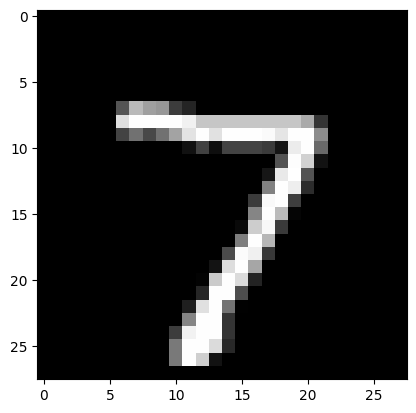

In [125]:
img,label= test_dataset[0]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 9 Predicted 9


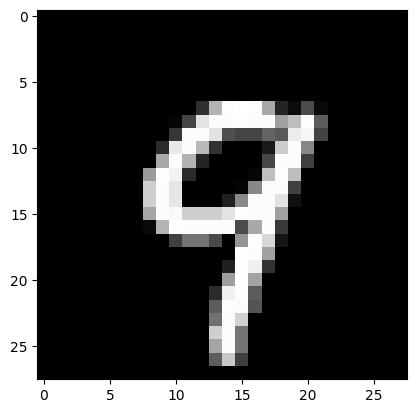

In [126]:
img,label= test_dataset[12]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 6 Predicted 6


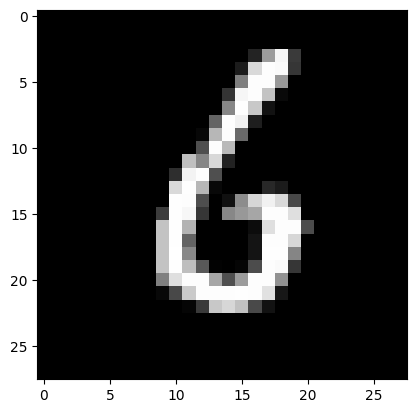

In [127]:
img,label= test_dataset[50]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 1 Predicted 1


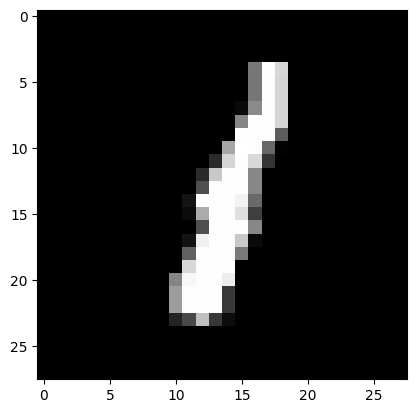

In [128]:
img,label= test_dataset[89]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 1 Predicted 1


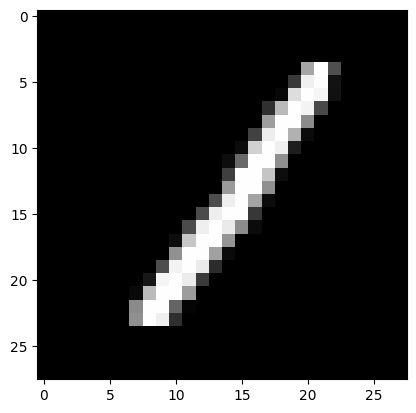

In [129]:
img,label= test_dataset[8995]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 7 Predicted 7


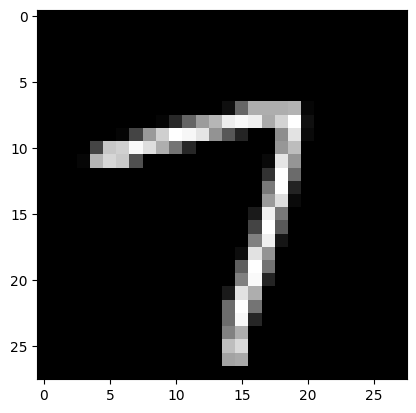

In [130]:
img,label= test_dataset[852]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 6 Predicted 6


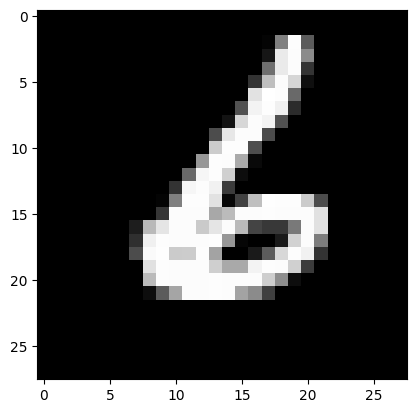

In [131]:
img,label= test_dataset[7512]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

Label 2 Predicted 8


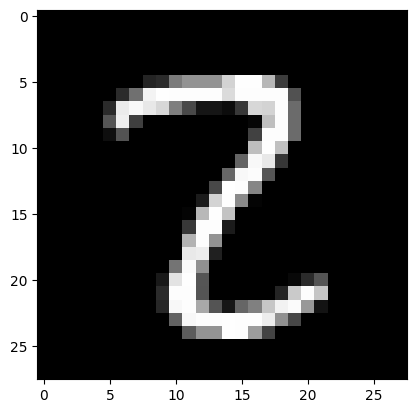

In [132]:
img,label= test_dataset[1839]
plt.imshow(img[0],cmap='gray')
print('Label',label,'Predicted',predict_image(img,model))

In [133]:
test_loader = DataLoader(test_dataset,batch_size=256)
result= evaluate(model,test_loader)
result

{'Val_loss': 1.1847127676010132, 'val_acc': 0.8148437738418579}

In [135]:
torch.save(model.state_dict(),'mnist-logistic.pth')

model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0065, -0.0138,  0.0293,  ..., -0.0308,  0.0334, -0.0125],
                      [ 0.0050,  0.0292, -0.0031,  ..., -0.0138,  0.0063,  0.0237],
                      [ 0.0297,  0.0343, -0.0254,  ..., -0.0297,  0.0066,  0.0312],
                      ...,
                      [ 0.0246,  0.0120,  0.0344,  ...,  0.0025, -0.0311, -0.0050],
                      [-0.0308, -0.0272, -0.0345,  ...,  0.0282,  0.0326, -0.0206],
                      [ 0.0155,  0.0113,  0.0203,  ..., -0.0223,  0.0125,  0.0110]])),
             ('linear.bias',
              tensor([ 0.0008,  0.0789,  0.0081, -0.0165,  0.0208, -0.0245,  0.0312, -0.0201,
                       0.0082,  0.0172]))])